<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/satisfaction.png'/></center>

### **고객 만족도 예측을 통한 서비스 개선**
# **단계 3: 모델 추가 학습**

## **미션 설명**

- 이번 단계에서는 다음과 같이 3개의 미션을 수행합니다.

### 미션 8: 전처리 파이프라인 만들기

- 새로운 학습용/검증용 데이터에 대해 매번 전처리 작업을 수행해야 합니다.
- 반복되는 전처리 작업은 비효율적인 업무 중 하나입니다.
- 이러한 문제를 해결하기 위해 다음과 같은 처리를 일괄 수행하는 파이프라인 함수를 만듭니다.
    - 결측치 처리
    - Target 값 0/1로 변경
    - 불필요한 변수 제거
    - 라벨 인코딩
    - 가변수화
    - x, y 분리
    - x 스케일링 등

### 미션 9: 기본 모델로 예측 및 평가

- 이전 과정에서 만든 모델이 기본 모델(Base Model)입니다.
- 새로 전달 받은 평가용 데이터로 기존에 만든 모델의 성능을 평가해봅니다.

### 미션 10: 추가 학습

- 문제 상황에 맞게 가장 적절한 방법으로 모델 추가 학습을 진행합니다.
- 추가 학습 후 이전에 평가했던 새로운 평가 데이터로 다시 평가해 성능 향상을 확인합니다.

## **※ 코드 셀은 충분히 추가해 사용합니다.**

## **1. 환경설정**

### (1) 구글 드라이브 연결 및 경로 설정

- 다음 구문을 실행에 구글 코랩에서 사용 가능하게 연결합니다.

In [ ]:
# 구글 드라이브 연결 & 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/Aivle/project01/'
else:
    path = ''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### (2) 라이브러리 불러오기

- 이후에 사용할 라이브러리를 모두 불러옵니다.

In [ ]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import *

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.backend import clear_session
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (3) 학습 곡선 시각화 함수 만들기

- 모델링 수행 시 학습 상황을 시각화해 확인하기 위한 함수를 만듭니다.

In [ ]:
# 함수 만들기
def dl_history_plot(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history['loss'], label='Train Loss', marker='.')
    plt.plot(history['val_loss'], label='Validation Loss', marker='.')

    plt.title('Learning Curve', size=15, pad=20)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

### (4) 기본 모델 및 데이터 불러오기

- 우선 이전 과정에서 저장한 모델을 불러와 base_model로 선언합니다.
    - path + 'base_model.keras' →  base_model
- **load_model()** 함수를 사용합니다.


In [ ]:
# 모델 불러오기
base_model = load_model(path + 'base_model.keras')

- 이전 과정에서 저장한 스케일러를 불러와 scaler 변수에 저장합니다.
    - path + 'scaler.pkl' →  scaler
- **joblib.load()** 함수를 사용합니다.

In [ ]:
# 스케일러 불러오기
scaler = joblib.load(path + 'scaler.pkl')

- 이전 과정에서 저장한 파일을 읽어와 new_test, new_train 데이터프레임을 만듭니다.
    - path + 'new_test.csv' → new_test
    - path + 'new_train.csv' → new_train

In [ ]:
# 파일 불러오기
new_test = pd.read_csv(path + 'new_test.csv')
new_train = pd.read_csv(path + 'new_train.csv')

## **2. 미션 8: 전처리 파이프라인 만들기**

- 다음 과정을 일괄 처리한 후 x, y를 반환하는 함수를 만듭니다.
    - 결측치 처리
    - Target 값 0/1로 변경
    - 불필요한 변수 제거
    - 라벨 인코딩
    - 가변수화
    - x, y 분리
    - x 스케일링 등
- 함수 이름은 **build_model_input** 로 지정합니다.
- 다음과 같이 사용할 수 있어야 합니다.
    - 예1) x_val, y_val = build_model_input(new_test)
    - 예2) x_trian, y_train = build_model_input(new_train)


In [ ]:
# 함수 만들기
def build_model_input(data):

  # 1. 결측치 처리
  df = data.copy()

  #수치형 -> 중앙값
  num_cols = df.select_dtypes(include=['number']).columns
  df[num_cols] = df[num_cols].fillna(df[num_cols].median())

  #범주형 -> 최빈값
  cat_cols = df.select_dtypes(include=['object','category']).columns
  df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

  # 2. 값 변경
  target = 'Satisfaction'
  df['Satisfaction'] = df['Satisfaction'].map({
                          'Satisfied': 1,
                            'Neutral or Dissatisfied': 0
                          })

  # 3. 변수 제거
  drop_cols = ['ID','Unnamed: 0']
  df.drop(columns=drop_cols, inplace=True)


  # 4. 라벨 인코딩
  cat_cols = ['Gender','Customer Type','Type of Travel','Class']
  for col in cat_cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])


  # 5. 가변수화
  # 설문 범주 정의
  categories = [0, 1, 2, 3, 4, 5]

  # 가변수화 대상 변수
  dumm_cols = ['Inflight wifi service', 'Departure/Arrival time convenient',
              'Ease of Online booking', 'Gate location', 'Food and drink',
               'Online boarding', 'Seat comfort', 'Inflight entertainment',
               'On-board service',  'Leg room service', 'Baggage handling',
               'Checkin service', 'Inflight service', 'Cleanliness']

  # Category 형 변수로 변환
  for col in dumm_cols:
    df[col] = pd.Categorical(df[col], categories=categories)

  # 가변수화
  df = pd.get_dummies(data=df, columns=dumm_cols, drop_first=True, dtype=int)

  # 6. x, y 분리
  x=df.drop(columns='Satisfaction')
  y=df.loc[:,'Satisfaction']

  # 7. 스케일링
  x = scaler.transform(x)

  # 반환
  return x, y

- 점검: 다음 구문이 잘 수행되어 x_val, y_val이 분리되어야 합니다.


In [ ]:
# x_val, y_val 나누기
x_val, y_val = build_model_input(new_test)

# 확인
print(x_val.shape)
print(y_val.shape)

(350, 78)
(350,)


## **3. 미션 9: 기본 모델로 예측 및 평가**

### (1) 데이터 전처리

- new_test 데이터프레임을 x_val, y_val로 분리합니다.

In [ ]:
x_val,y_val = build_model_input(new_test)

In [ ]:
new_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         350 non-null    int64  
 1   ID                                 350 non-null    int64  
 2   Gender                             350 non-null    object 
 3   Customer Type                      350 non-null    object 
 4   Age                                340 non-null    float64
 5   Type of Travel                     350 non-null    object 
 6   Class                              350 non-null    object 
 7   Flight Distance                    350 non-null    int64  
 8   Inflight wifi service              335 non-null    float64
 9   Departure/Arrival time convenient  350 non-null    int64  
 10  Ease of Online booking             350 non-null    int64  
 11  Gate location                      350 non-null    int64  

### (2) 예측 및 평가

- 새로운 데이터에 대한 예측과 평가를 수행합니다.

In [ ]:
y_pred = base_model.predict(x_val)
y_pred = np.where(y_pred>=0.5,1,0)

print(classification_report(y_val,y_pred))

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
              precision    recall  f1-score   support

           0       0.99      0.83      0.91       191
           1       0.83      0.99      0.91       159

    accuracy                           0.91       350
   macro avg       0.91      0.91      0.91       350
weighted avg       0.92      0.91      0.91       350



## **4. 미션 10: 모델 추가 학습**

### (1) 학습용 데이터 준비

- new_train 데이터프레임을 x_train, y_train으로 분리합니다.

In [ ]:
x_train, y_train = build_model_input(new_train)

### (2) 방법 1: 모델 초기화

- 이전에 만들었던 성능이 좋았던 모델과 같은 모델을 만들어 학습 후 성능을 확인합니다.

In [ ]:
clear_session()

nfeatures = x_train.shape[1]

model_best = Sequential([
    Input(shape=(nfeatures,)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.3),
    Dense(8, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid'),
])

model_best.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,841 (30.63 KB)

 Trainable params: 7,841 (30.63 KB)

 Non-trainable params: 0 (0.00 B)

- 학습 방법을 설정하고 학습을 수행합니다.

In [ ]:
es = EarlyStopping(monitor='val_loss',min_delta=0.01, patience=10, verbose=1)
model_best.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy')
hist = model_best.fit(x_train,y_train,epochs=200, validation_split=0.2, callbacks=[es],verbose=0).history

Epoch 30: early stopping


- 학습 곡선을 확인합니다.

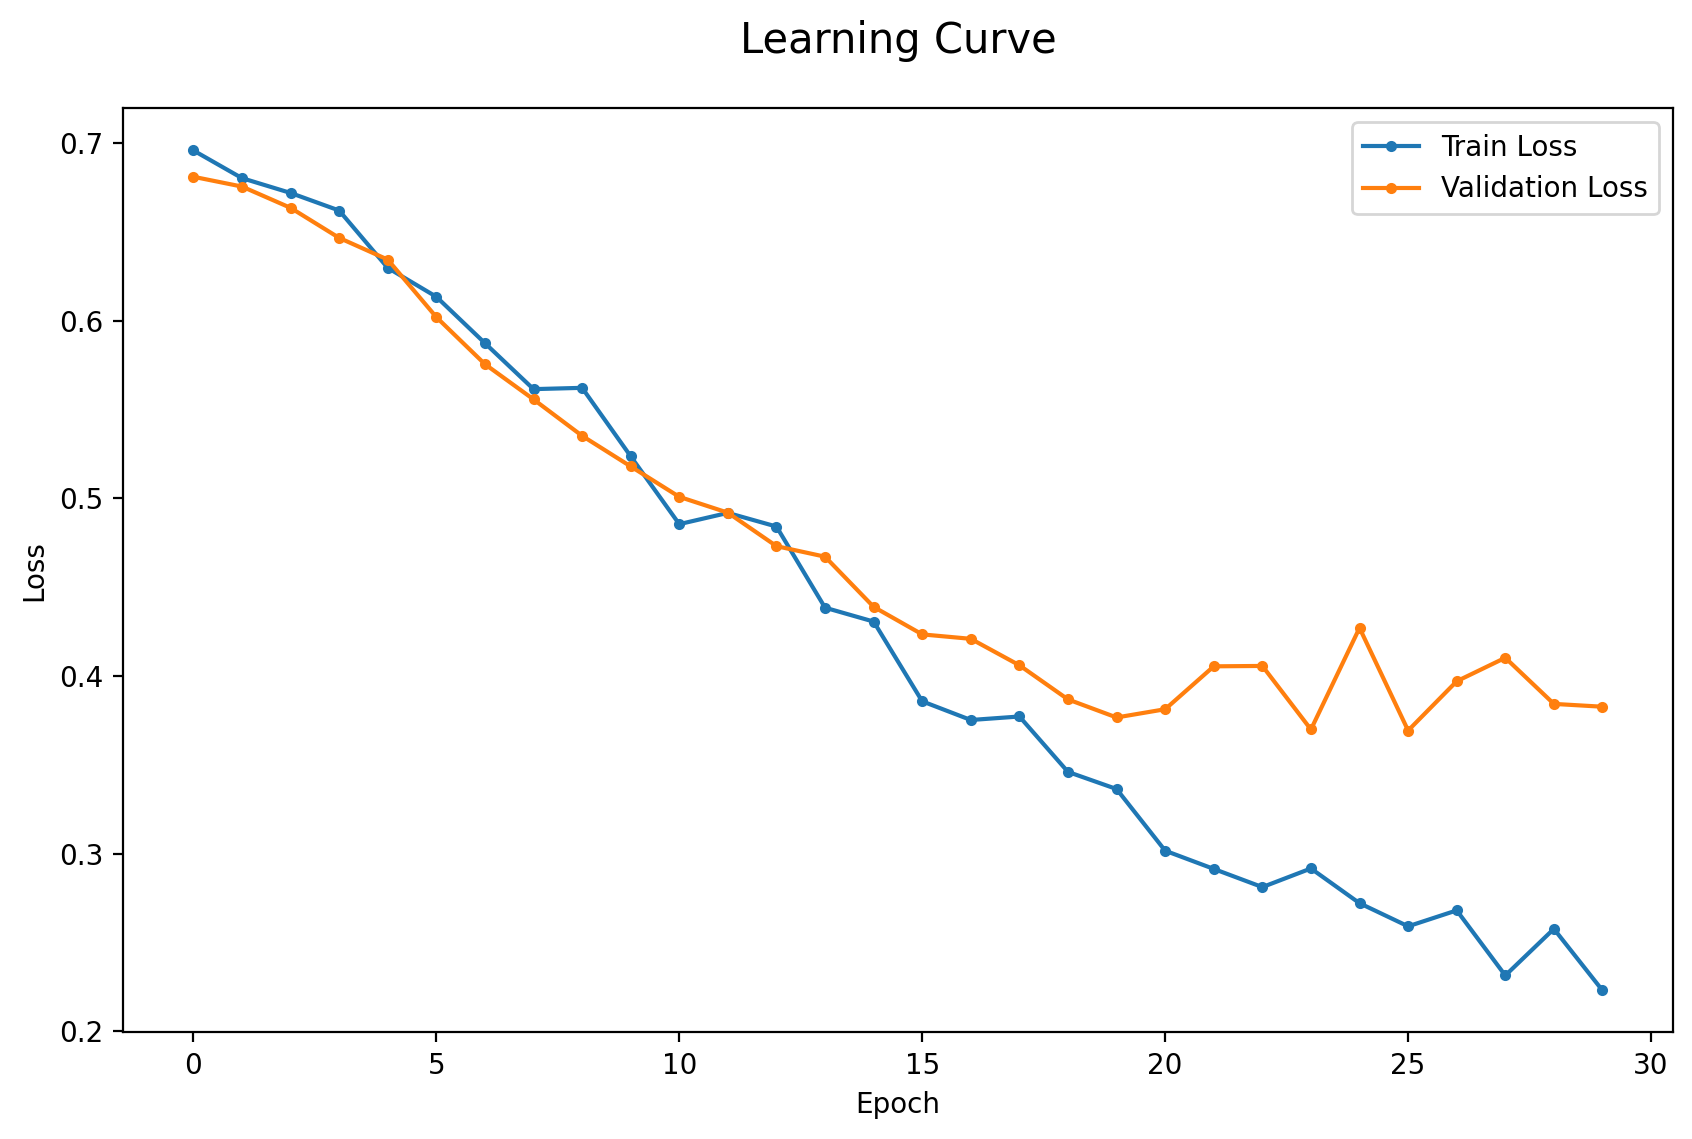

In [ ]:
dl_history_plot(hist)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [ ]:
y_pred = model_best.predict(x_val)
y_pred = np.where(y_pred>=0.5,1,0)
print(classification_report(y_val,y_pred))

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       191
           1       0.89      0.91      0.90       159

    accuracy                           0.91       350
   macro avg       0.91      0.91      0.91       350
weighted avg       0.91      0.91      0.91       350



### (3) 방법 2: 추가 학습

- 기본 모델을 기반으로 모델을 선언하고 추가 학습 후 성능을 확인합니다.

In [ ]:
model = base_model

- 학습 방법을 설정하고 학습을 수행합니다.

In [ ]:
hist = base_model.fit(x_train,
                            y_train,
                            epochs=30,
                            callbacks=[es],
                            validation_split=0.2
                            ).history

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.4409 - val_loss: 0.2663
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2551 - val_loss: 0.2545
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2196 - val_loss: 0.2634
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2021 - val_loss: 0.2542
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1997 - val_loss: 0.2543
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1827 - val_loss: 0.2474
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1850 - val_loss: 0.2661
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1965 - val_loss: 0.2574
Epoch 9/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1809 - val_loss: 0.2518
Epoch 10/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1540 - val_loss: 0.2548
Epoch 11/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1617 - val_loss: 0.2727
Epoch 12/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1

- 학습 곡선을 확인합니다.

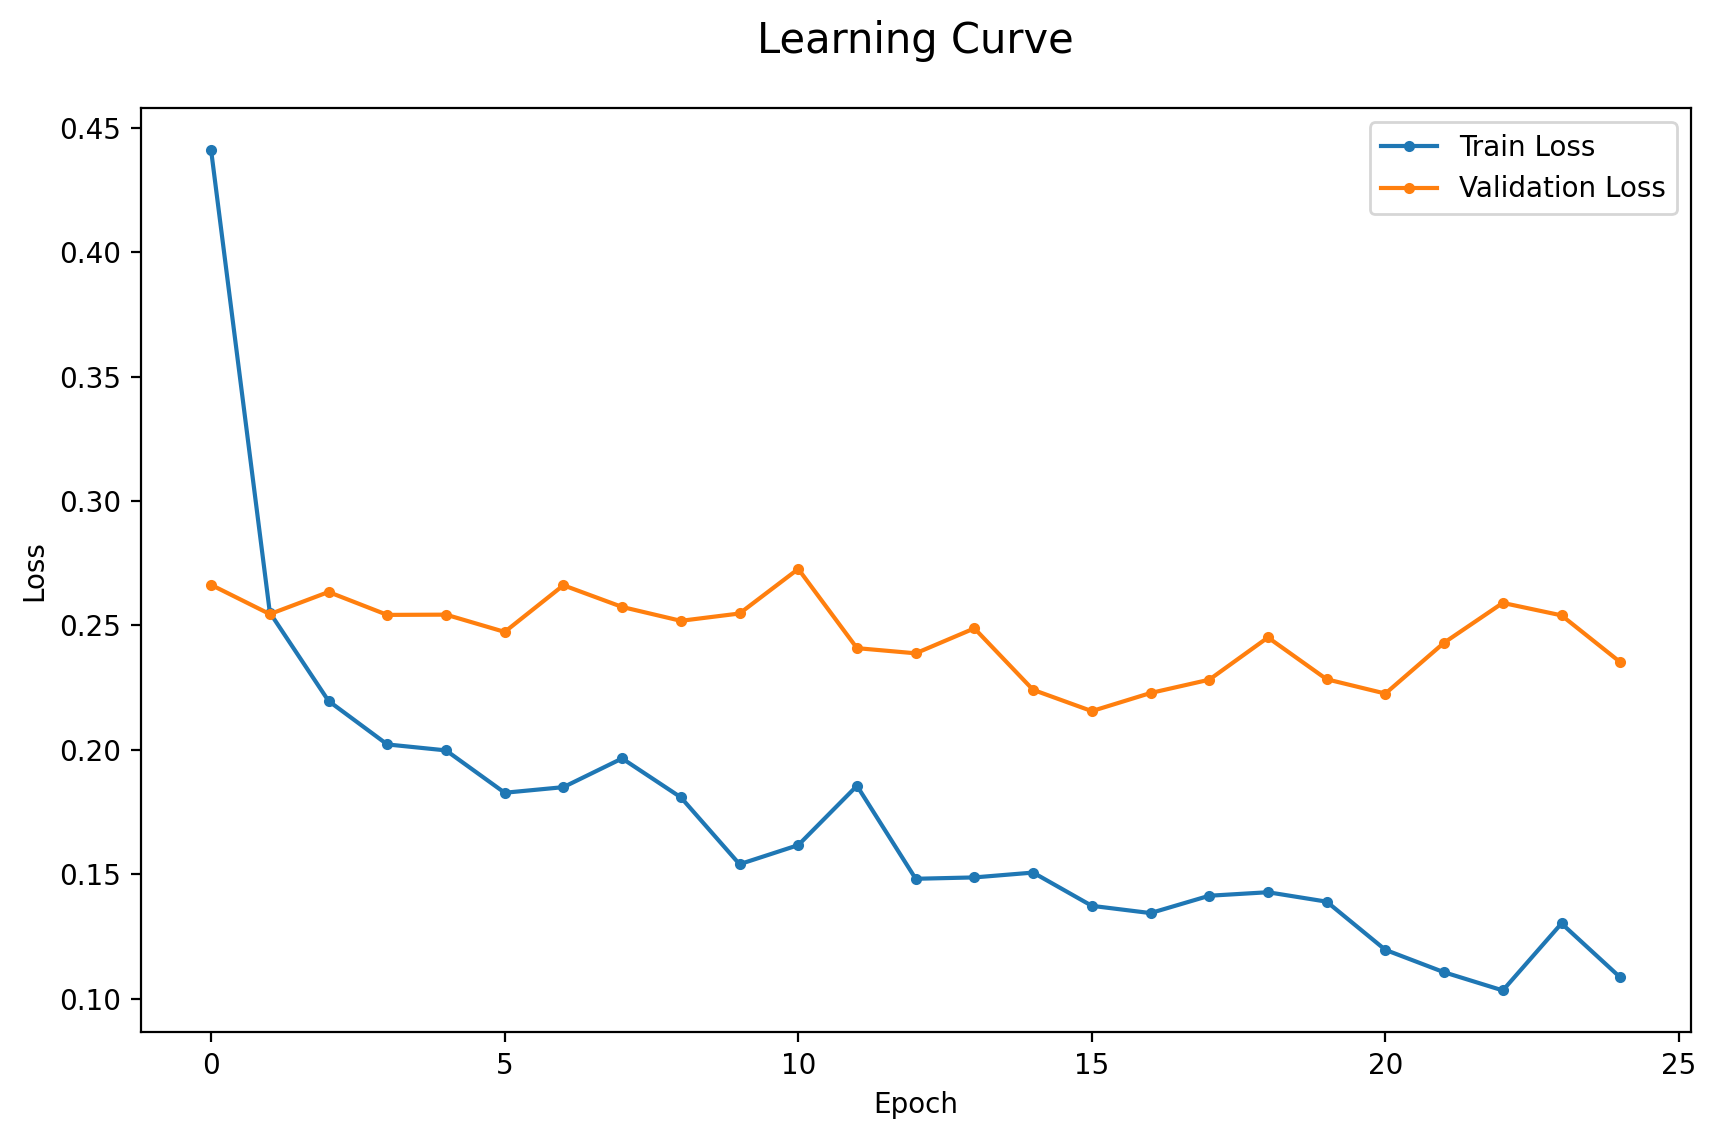

In [ ]:
dl_history_plot(hist)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [ ]:
y_pred = base_model(x_val)
y_pred = np.where(y_pred >=0.5,1,0)
print(classification_report(y_val,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93       191
           1       0.93      0.90      0.92       159

    accuracy                           0.93       350
   macro avg       0.93      0.92      0.92       350
weighted avg       0.93      0.93      0.93       350



### (4) 방법 3: 미세조정

- 기본 모델의 앞쪽 레이어 일부의 학습 기능을 비활성화합니다.
- 기본 모델을 기반으로 레이어를 추가한 모델을 선언합니다.
- 추가 학습을 진행한 뒤 성능을 확인합니다.

In [ ]:
# 모델 불러오기
base_model = load_model(path + 'base_model.keras')
# base_model.summary()
# 마지막 레이어 제거
base_model.pop()

<Dense name=dense_5, built=True>

- 학습 방법을 설정하고 학습을 수행합니다.

In [ ]:
for layer in base_model.layers[:-3]:
  layer.trainable=False
#모델 선언
model = Sequential([
    base_model,
    Dense(8,activation='relu'),
    Dense(1,activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy')
hist = model.fit(x_train,
                 y_train,
                 epochs=100,
                 callbacks=[es],
                 validation_split=0.2).history

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 156ms/step - loss: 0.5830 - val_loss: 0.4924
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5632 - val_loss: 0.4594
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5219 - val_loss: 0.4338
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5501 - val_loss: 0.4086
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4865 - val_loss: 0.3857
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4705 - val_loss: 0.3738
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4096 - val_loss: 0.3627
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4249 - val_loss: 0.3514
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4369 - val_loss: 0.3388
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3788 - val_loss: 0.3254
Epoch 10: early stopping


- 학습 곡선을 확인합니다.

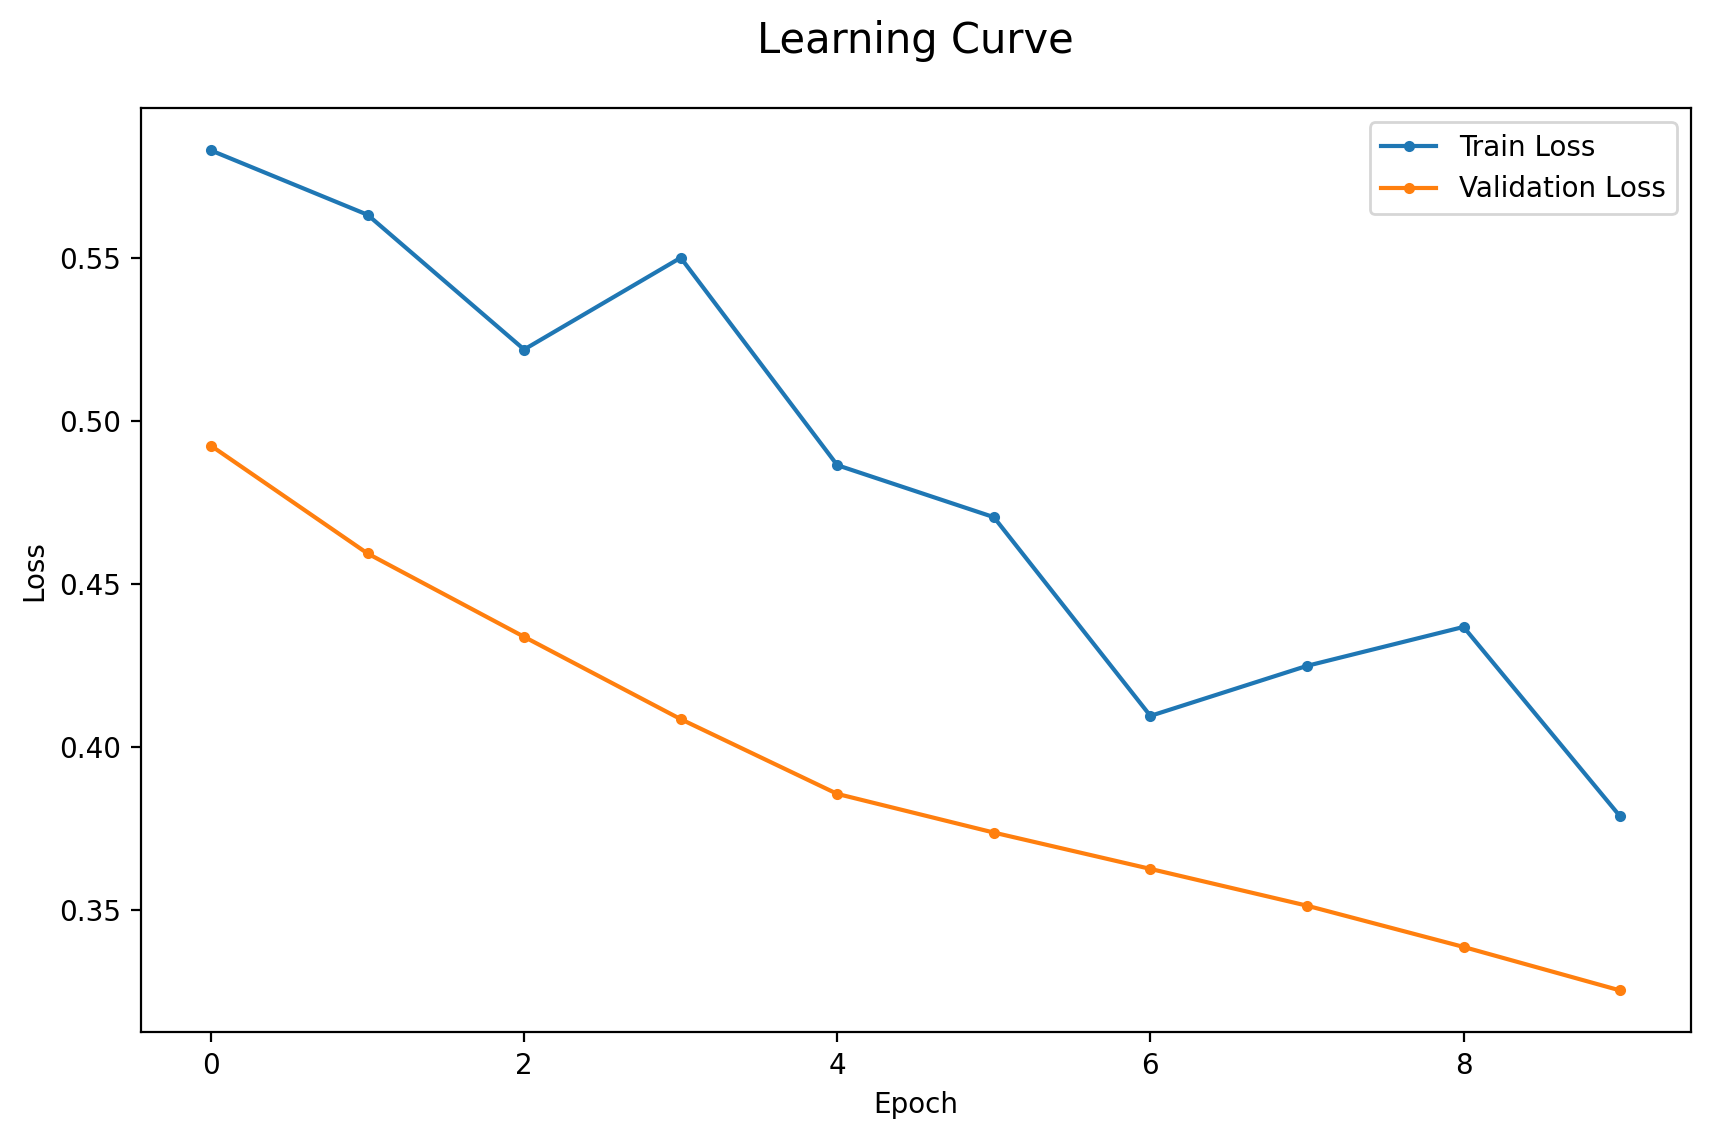

In [ ]:
dl_history_plot(hist)

- 검증 데이터로 예측 및 평가를 수행합니다.

In [ ]:
y_pred = model.predict(x_val)
y_pred = np.where(y_pred >= 0.5,1,0)
print(classification_report(y_val,y_pred))

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
              precision    recall  f1-score   support

           0       0.97      0.88      0.93       191
           1       0.88      0.97      0.92       159

    accuracy                           0.92       350
   macro avg       0.92      0.93      0.92       350
weighted avg       0.93      0.92      0.92       350

